# Hands-On Linear Algebra, Chapter 8: Eigenvalues and Eigenvectors

Every chapter so far has taken the basis as given. Chapter 3 showed that the
choice was ours to make, and that a good choice can turn a hard description into
an easy one. Chapter 4 showed that a matrix is only a transformation's
*description* in a chosen basis.

Put those together and a question presents itself:

> Given a particular square matrix, **is there a basis in which it becomes as
> simple as possible?**

When the answer is yes, the simplification is drastic. Most matrices have
special directions that they do not rotate at all, but merely stretch. Use those
directions as your basis and the matrix becomes **diagonal**: no mixing between
coordinates, just $n$ independent scalings. Repeated application, which is
otherwise a mess of matrix multiplications, becomes raising $n$ numbers to a
power.

| Module | What you build | Data |
|---|---|---|
| 1 | The **invariant directions**, found by looking before computing | — |
| 2 | The characteristic polynomial, and **power iteration** from scratch | — |
| 3 | **Diagonalisation** $A = PDP^{-1}$, and $A^k$ made trivial, with Fibonacci in closed form | — |
| 4 | Where it **fails**: defective matrices, complex eigenvalues, and the symmetric case that never fails | — |
| 5 | **Markov chains and PageRank**: the dominant eigenvector as an answer to a real question | — |

**How each concept is presented**, in three passes over the same idea:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read a textbook.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** a couple of seconds on CPU; no data downloads. Assumes Chapters 1–7.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=3, suppress=True)

print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module 1 — Directions That Do Not Turn

## 1.1 Look before computing

🧠 **The intuition.** Apply a matrix to a vector and two things generally
happen: the vector changes length, and it changes direction. For *some* vectors,
only the first happens. Those are the **eigenvectors**, the axes along which
the transformation is nothing more complicated than a scaling, and the scale
factor is the **eigenvalue**.

📐 **The math.** $\mathbf{v} \neq \mathbf{0}$ is an eigenvector of $A$ with
eigenvalue $\lambda$ if

$$ A\mathbf{v} = \lambda \mathbf{v} $$

Note that eigenvectors come in whole lines: if $\mathbf{v}$ qualifies, so does
$c\mathbf{v}$ for any $c \ne 0$. What is really being singled out is a
*direction*, and software returns unit-length representatives by convention.

💻 **The code.** Before any formula: apply $A$ to many unit vectors and measure
how far each one turned.

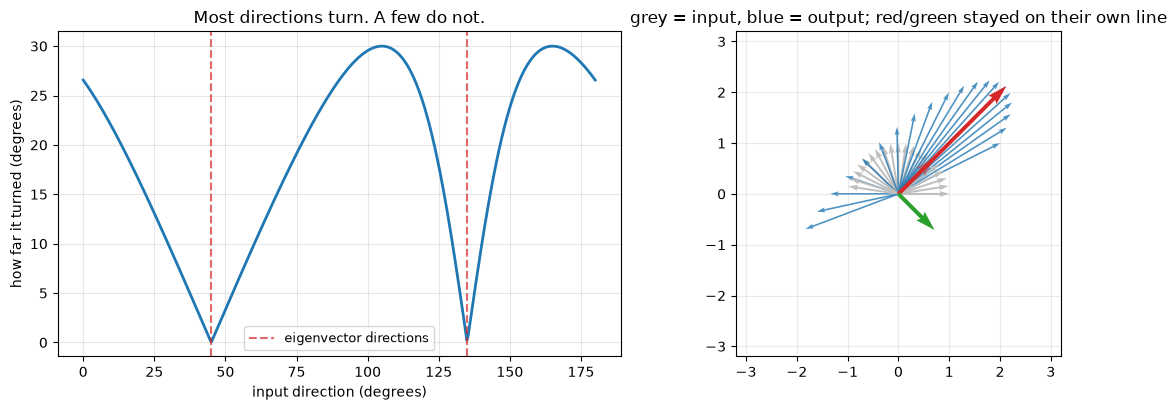

A @ (1, 1)   = [3. 3.]  = 3 × (1, 1)
A @ (1, -1)  = [ 1. -1.]  = 1 × (1, -1)


In [2]:
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])

angles = np.linspace(0, np.pi, 400)                     # directions (a line covers two)
V = np.stack([np.cos(angles), np.sin(angles)])
AV = A @ V
turn = np.degrees(np.arccos(np.clip(np.sum(V * (AV / np.linalg.norm(AV, axis=0)), axis=0), -1, 1)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(np.degrees(angles), turn, lw=2)
axes[0].set_xlabel("input direction (degrees)"); axes[0].set_ylabel("how far it turned (degrees)")
axes[0].set_title("Most directions turn. A few do not.")
for j, vec0 in enumerate(np.linalg.eig(A)[1].real.T):   # where numpy says they are
    axes[0].axvline(np.degrees(np.arctan2(vec0[1], vec0[0])) % 180,
                    color="tab:red", ls="--", alpha=0.7,
                    label="eigenvector directions" if j == 0 else None)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

ax = axes[1]
for k in range(0, 400, 20):
    ax.quiver(0, 0, *V[:, k], angles="xy", scale_units="xy", scale=1,
              color="0.75", width=0.006)
    ax.quiver(0, 0, *AV[:, k], angles="xy", scale_units="xy", scale=1,
              color="tab:blue", width=0.005, alpha=0.8)
for vec, col in [(np.array([1, 1]) / np.sqrt(2), "tab:red"),
                 (np.array([1, -1]) / np.sqrt(2), "tab:green")]:
    ax.quiver(0, 0, *(A @ vec), angles="xy", scale_units="xy", scale=1,
              color=col, width=0.012, zorder=5)
    ax.quiver(0, 0, *vec, angles="xy", scale_units="xy", scale=1,
              color=col, width=0.012, alpha=0.45, zorder=5)
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2); ax.set_aspect("equal"); ax.grid(alpha=0.25)
ax.set_title("grey = input, blue = output; red/green stayed on their own line")
plt.tight_layout(); plt.show()

for vec, name in [(np.array([1.0, 1.0]), "(1, 1)"), (np.array([1.0, -1.0]), "(1, -1)")]:
    print(f"A @ {name:<8} = {A @ vec}  = {(A @ vec)[0] / vec[0]:.0f} × {name}")

The two red-dashed troughs in the left panel are directions that came out
pointing exactly where they went in. For this matrix they are $(1,1)$, stretched
by 3, and $(1,-1)$, left alone (stretched by 1). Those are the eigenvectors, and
we found them by *looking*, before writing down a single determinant.

---
# Module 2 — Finding Them

## 2.1 The characteristic polynomial

📐 **The math.** Rearrange the definition:

$$ A\mathbf{v} = \lambda\mathbf{v}
\iff (A - \lambda I)\mathbf{v} = \mathbf{0} $$

We need a **non-zero** $\mathbf{v}$ in the null space of $A - \lambda I$. By
Chapter 6's equivalence chain, a non-trivial null space means the matrix is
singular, which means:

$$ \boxed{\;\det(A - \lambda I) = 0\;} $$

That is a degree-$n$ polynomial in $\lambda$, the **characteristic polynomial**,
and its roots are the eigenvalues. For our $2\times2$:

$$ \det \begin{bmatrix} 2-\lambda & 1 \\ 1 & 2-\lambda \end{bmatrix}
= (2-\lambda)^2 - 1 = \lambda^2 - 4\lambda + 3 = (\lambda-1)(\lambda-3) $$

Two useful shortcuts fall out of the coefficients: the eigenvalues sum to the
**trace** and multiply to the **determinant**.

💻 **The code.**

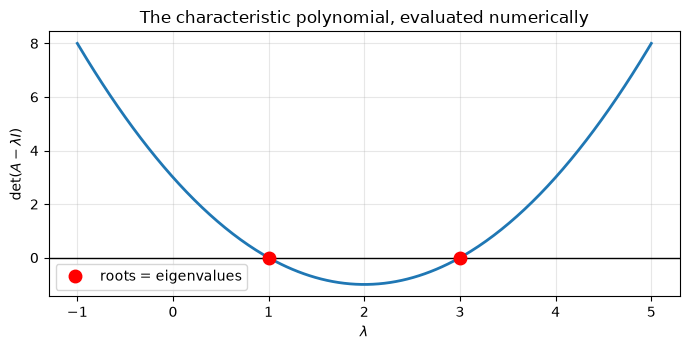

largest imaginary part: 0.0
eigenvalues : [3. 1.]
eigenvectors (columns, unit length):
 [[ 0.707 -0.707]
 [ 0.707  0.707]]

sum of eigenvalues = 4.0  trace(A) = 4.0
product            = 3.0  det(A)   = 2.9999999999999996
check A v = λ v for λ=3: True
check A v = λ v for λ=1: True


In [3]:
lams = np.linspace(-1, 5, 300)
char_poly = [np.linalg.det(A - l * np.eye(2)) for l in lams]

plt.figure(figsize=(7, 3.6))
plt.plot(lams, char_poly, lw=2)
plt.axhline(0, color="k", lw=1)
plt.plot([1, 3], [0, 0], "ro", ms=9, label="roots = eigenvalues")
plt.xlabel("$\\lambda$"); plt.ylabel("$\\det(A - \\lambda I)$"); plt.legend(); plt.grid(alpha=0.3)
plt.title("The characteristic polynomial, evaluated numerically")
plt.tight_layout(); plt.show()

vals, vecs = np.linalg.eig(A)
# np.linalg.eig always returns complex arrays, because a general matrix can have
# complex eigenvalues (Module 4). This one does not, so drop the zero imaginary parts.
print("largest imaginary part:", np.abs(vals.imag).max())
vals, vecs = vals.real, vecs.real

print("eigenvalues :", vals)
print("eigenvectors (columns, unit length):\n", vecs)
print("\nsum of eigenvalues =", vals.sum(), " trace(A) =", np.trace(A))
print("product            =", vals.prod(), " det(A)   =", np.linalg.det(A))
for i in range(2):
    print(f"check A v = λ v for λ={vals[i]:.0f}:",
          np.allclose(A @ vecs[:, i], vals[i] * vecs[:, i]))

## 2.2 Why nobody computes eigenvalues that way

🧠 **The intuition.** The characteristic polynomial is the right *definition*
and a terrible *algorithm*, the same trap as cofactor determinants in Chapter 6.
Two reasons: there is no formula for the roots of a general polynomial of degree
5 or more (Abel–Ruffini), and polynomial root-finding is numerically vicious,
with tiny coefficient changes moving roots enormously.

Real algorithms are **iterative**, and the simplest one is a good demonstration
of what eigenvalues *do*.

📐 **The math: power iteration.** Take any starting vector and keep applying
$A$, renormalising each time. Write the start in the eigenbasis:

$$ \mathbf{x}_0 = c_1\mathbf{v}_1 + \cdots + c_n\mathbf{v}_n
\;\Longrightarrow\; A^k\mathbf{x}_0 = c_1\lambda_1^k\mathbf{v}_1 + \cdots + c_n\lambda_n^k\mathbf{v}_n $$

Divide by $\lambda_1^k$ (the largest): every other term carries
$(\lambda_i/\lambda_1)^k \to 0$. The largest eigenvalue **takes over**, at a rate
set by the ratio $|\lambda_2/\lambda_1|$.

💻 **The code.**

power iteration -> 6.66907909
np.linalg.eigvalsh -> [6.669 3.476 1.855]
eigenvector: [0.631 0.172 0.756]
A v - λ v  : [0. 0. 0.]


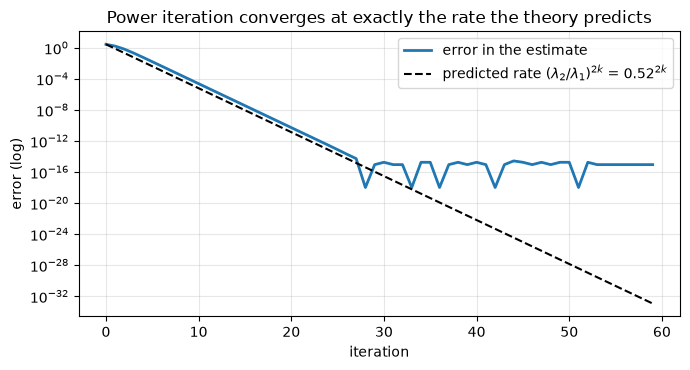

In [4]:
def power_iteration(M, n_iter=100, x0=None):
    """Repeatedly apply M and renormalise. Returns (eigenvalue, eigenvector, history)."""
    x = rng.normal(size=M.shape[0]) if x0 is None else np.array(x0, dtype=float)
    x /= np.linalg.norm(x)
    history = []
    for _ in range(n_iter):
        y = M @ x
        lam = x @ y                                  # Rayleigh quotient
        x = y / np.linalg.norm(y)
        history.append(lam)
    return lam, x, np.array(history)

B = np.array([[4.0, 1.0, 2.0],
              [1.0, 3.0, 0.0],
              [2.0, 0.0, 5.0]])
true_vals = np.sort(np.linalg.eigvalsh(B))[::-1]
lam, vec, hist = power_iteration(B, n_iter=60)

print("power iteration ->", round(lam, 8))
print("np.linalg.eigvalsh ->", true_vals)
print("eigenvector:", np.round(vec, 6))
print("A v - λ v  :", np.round(B @ vec - lam * vec, 10))

ratio = abs(true_vals[1] / true_vals[0])
plt.figure(figsize=(7, 3.8))
plt.semilogy(np.abs(hist - true_vals[0]) + 1e-18, lw=2, label="error in the estimate")
plt.semilogy(np.abs(hist[0] - true_vals[0]) * ratio ** (2 * np.arange(len(hist))), "k--",
             label=f"predicted rate $(\\lambda_2/\\lambda_1)^{{2k}}$ = {ratio:.2f}$^{{2k}}$")
plt.xlabel("iteration"); plt.ylabel("error (log)"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.title("Power iteration converges at exactly the rate the theory predicts")
plt.tight_layout(); plt.show()

The measured error tracks the predicted curve. (The exponent is $2k$ rather than
$k$ because the Rayleigh quotient converges quadratically for symmetric
matrices, a free bonus of symmetry that Module 4 explains.)

Power iteration is not a toy: it is how PageRank was originally computed, at web
scale, and Module 5 does exactly that on a small graph.

---
# Module 3 — Diagonalisation: The Basis Where the Matrix Is Simple

## 3.1 $A = PDP^{-1}$

🧠 **The intuition.** Suppose $A$ has $n$ independent eigenvectors. Use them as
a basis (Chapter 3 says we may). In *that* coordinate system the transformation
does nothing but scale each axis, so its matrix is diagonal. $A = PDP^{-1}$ is
that statement written out, and the three factors read right to left as a
sentence:

1. $P^{-1}$ translates the input into eigen-coordinates,
2. $D$ scales each coordinate by its eigenvalue,
3. $P$ translates the result back to standard coordinates.

📐 **The math.** With $P = [\mathbf{v}_1 | \cdots | \mathbf{v}_n]$ and
$D = \text{diag}(\lambda_1, \dots, \lambda_n)$:

$$ AP = PD \iff A = PDP^{-1} $$

and the payoff is powers:

$$ A^k = (PDP^{-1})(PDP^{-1})\cdots(PDP^{-1}) = P D^k P^{-1} $$

because every interior $P^{-1}P$ collapses to $I$. Raising a diagonal matrix to
a power is raising $n$ numbers to a power.

💻 **The code.**

In [5]:
vals, P = np.linalg.eig(A)
vals, P = vals.real, P.real                # real, as checked in Module 2
D = np.diag(vals)

print("P =\n", P, "\nD =\n", D)
print("\nP D P^-1 == A:", np.allclose(P @ D @ np.linalg.inv(P), A))

k = 12
direct = np.linalg.matrix_power(A, k)
via_eig = P @ np.diag(vals ** k) @ np.linalg.inv(P)
print(f"\nA^{k} directly:\n", direct)
print(f"A^{k} via P D^{k} P^-1:\n", np.round(via_eig, 6))
print("identical:", np.allclose(direct, via_eig))
print("\nthe transformation in its own eigenbasis (P^-1 A P):\n",
      np.round(np.linalg.inv(P) @ A @ P, 10), "-> diagonal, as promised")

P =
 [[ 0.707 -0.707]
 [ 0.707  0.707]] 
D =
 [[3. 0.]
 [0. 1.]]

P D P^-1 == A: True

A^12 directly:
 [[265721. 265720.]
 [265720. 265721.]]
A^12 via P D^12 P^-1:
 [[265721. 265720.]
 [265720. 265721.]]
identical: True

the transformation in its own eigenbasis (P^-1 A P):
 [[ 3.  0.]
 [-0.  1.]] -> diagonal, as promised


## 3.2 Fibonacci, in closed form

🧠 **The intuition.** The Fibonacci rule $F_{k+1} = F_k + F_{k-1}$ is a linear
transformation applied over and over:

$$ \begin{bmatrix} F_{k+1} \\ F_k \end{bmatrix} =
\begin{bmatrix} 1 & 1 \\ 1 & 0 \end{bmatrix}
\begin{bmatrix} F_k \\ F_{k-1} \end{bmatrix} $$

so $F_k$ is an entry of $M^k$. Diagonalise $M$ and the recursion collapses into
a formula, and the golden ratio appears, not by magic, but as the dominant
eigenvalue.

💻 **The code.**

In [6]:
M = np.array([[1.0, 1.0], [1.0, 0.0]])
vals_f, P_f = np.linalg.eig(M)
phi = (1 + np.sqrt(5)) / 2

print("eigenvalues:", vals_f)
print("golden ratio φ =", phi, "  and 1-φ =", 1 - phi)

def fib_matrix(k):
    return int(round(np.linalg.matrix_power(M, k)[0, 1]))

def fib_closed_form(k):
    """Binet's formula, which IS the diagonalisation written out."""
    return (phi ** k - (1 - phi) ** k) / np.sqrt(5)

print(f"\n{'k':>3} {'by matrix power':>16} {'closed form':>16} {'phi^k / sqrt 5':>16}")
for k in [5, 10, 20, 40]:
    print(f"{k:>3} {fib_matrix(k):>16} {fib_closed_form(k):>16.4f} {phi**k/np.sqrt(5):>16.4f}")

print("\nThe ratio of consecutive Fibonacci numbers converges to φ because the")
print("second eigenvalue |1 - φ| = 0.618 < 1 dies away: power iteration, in disguise.")
print("F(30)/F(29) =", fib_matrix(30) / fib_matrix(29), " φ =", phi)

eigenvalues: [ 1.618+0.j -0.618+0.j]
golden ratio φ = 1.618033988749895   and 1-φ = -0.6180339887498949

  k  by matrix power      closed form   phi^k / sqrt 5
  5                5           5.0000           4.9597
 10               55          55.0000          55.0036
 20             6765        6765.0000        6765.0000
 40        102334155   102334155.0000   102334155.0000

The ratio of consecutive Fibonacci numbers converges to φ because the
second eigenvalue |1 - φ| = 0.618 < 1 dies away: power iteration, in disguise.
F(30)/F(29) = 1.6180339887482036  φ = 1.618033988749895


---
# Module 4 — Where Diagonalisation Fails, and Where It Never Does

## 4.1 Two failure modes

🧠 **The intuition.** Diagonalisation needs $n$ *independent* eigenvectors.
Two things can go wrong.

**Defective matrices.** The shear $\begin{bmatrix}1&1\\0&1\end{bmatrix}$ has the
single eigenvalue 1 repeated, but only *one* eigenvector direction, the
horizontal one. Everything else genuinely turns. There is no basis of
eigenvectors, so no diagonalisation exists.

**Complex eigenvalues.** A rotation turns *every* real direction, so it has no
real eigenvectors at all. Its eigenvalues are complex, $e^{\pm i\theta}$, which
is a description rather than a defect: complex eigenvalues encode rotation, and
their magnitude encodes growth.

💻 **The code.**

In [7]:
shear = np.array([[1.0, 1.0], [0.0, 1.0]])
theta = np.pi / 4
rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

for name, Mz in [("shear", shear), ("rotation 45°", rot)]:
    vals_, vecs_ = np.linalg.eig(Mz)
    indep = np.linalg.matrix_rank(vecs_)
    print(f"{name}:")
    print(f"    eigenvalues: {np.round(vals_, 4)}")
    print(f"    independent eigenvectors: {indep} of 2 "
          f"-> {'diagonalisable' if indep == 2 else 'DEFECTIVE, not diagonalisable'}")
    if np.iscomplexobj(vals_) and np.any(np.abs(vals_.imag) > 1e-12):
        print(f"    |λ| = {np.abs(vals_[0]):.4f}, arg λ = {np.degrees(np.angle(vals_[0])):.1f}°"
              f"  <- the rotation angle, read straight off")
    print()

shear:
    eigenvalues: [1.+0.j 1.+0.j]
    independent eigenvectors: 1 of 2 -> DEFECTIVE, not diagonalisable

rotation 45°:
    eigenvalues: [0.707+0.707j 0.707-0.707j]
    independent eigenvectors: 2 of 2 -> diagonalisable
    |λ| = 1.0000, arg λ = 45.0°  <- the rotation angle, read straight off



## 4.2 Symmetric matrices: the case that always works

🧠 **The intuition.** If $A = A^\top$, everything goes right at once. The
eigenvalues are **real**, the eigenvectors can always be chosen **orthonormal**,
and diagonalisation always exists. Geometrically, a symmetric matrix is a pure
stretch along a set of perpendicular axes, with no rotation, no shear, and no
failure mode.

📐 **The math: the spectral theorem.** Every real symmetric $A$ can be written

$$ A = Q \Lambda Q^\top, \qquad Q^\top Q = I,\ \Lambda \text{ real diagonal} $$

Note $Q^{-1} = Q^\top$ (Chapter 7), so the "translate back" step is free. This is
the most useful theorem in applied linear algebra, because the matrices that
arise in practice (covariance matrices, Gram matrices $A^\top A$, graph
Laplacians, Hessians) are symmetric by construction.

💻 **The code.** Test the claim on random symmetric matrices, and confirm that
non-symmetric ones fail it.

In [8]:
N_TRIALS = 300        # <- knob

def spectral_check(make_matrix, label):
    """Are the eigenvalues real, and are the eigenvectors mutually perpendicular?"""
    max_imag = worst_cos = 0.0
    for _ in range(N_TRIALS):
        vals_, vecs_ = np.linalg.eig(make_matrix())
        max_imag = max(max_imag, np.max(np.abs(vals_.imag)))
        V = vecs_ / np.linalg.norm(vecs_, axis=0)
        G = np.abs(V.conj().T @ V)                  # |cos| between every pair
        np.fill_diagonal(G, 0.0)
        worst_cos = max(worst_cos, G.max())
    print(f"{label:<32} largest |Im λ|: {max_imag:.2e}   "
          f"largest |cos| between eigenvectors: {worst_cos:.3f}")

sym = lambda: (lambda Mz: (Mz + Mz.T) / 2)(rng.normal(size=(5, 5)))
spectral_check(sym, f"symmetric (over {N_TRIALS} trials)")
spectral_check(lambda: rng.normal(size=(5, 5)), f"non-symmetric ({N_TRIALS} trials)")

S = sym()
vals_s, Q = np.linalg.eigh(S)                       # eigh: for symmetric matrices
print(f"\nA = Q Λ Q^T reconstruction error: {np.linalg.norm(Q @ np.diag(vals_s) @ Q.T - S):.2e}")
print("eigenvalues (all real):", np.round(vals_s, 4))

symmetric (over 300 trials)      largest |Im λ|: 0.00e+00   largest |cos| between eigenvectors: 0.000
non-symmetric (300 trials)       largest |Im λ|: 2.68e+00   largest |cos| between eigenvectors: 1.000

A = Q Λ Q^T reconstruction error: 4.56e-15
eigenvalues (all real): [-2.382 -0.87  -0.511  0.642  1.666]


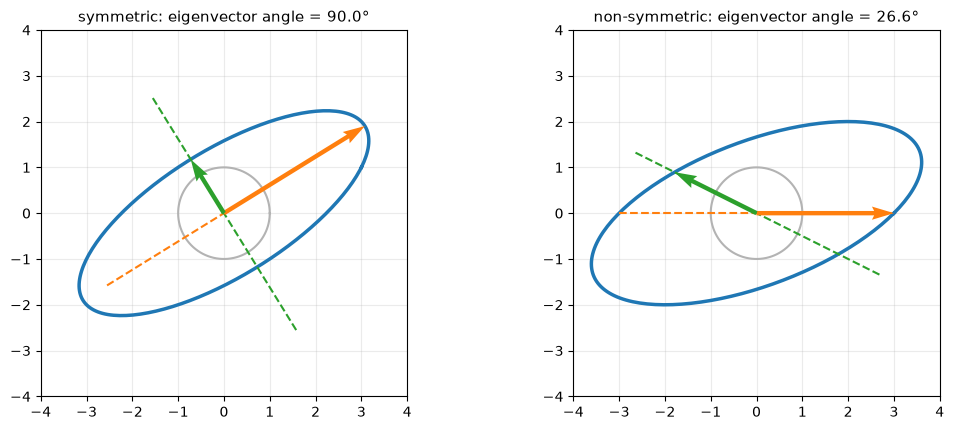

The symmetric matrix stretches along perpendicular axes, so the circle becomes
an ellipse aligned with them. The non-symmetric one has skewed eigen-axes.


In [9]:
S2 = np.array([[3.0, 1.0], [1.0, 2.0]])              # symmetric
NS = np.array([[3.0, 2.0], [0.0, 2.0]])              # not symmetric
circle = np.stack([np.cos(np.linspace(0, 2*np.pi, 200)), np.sin(np.linspace(0, 2*np.pi, 200))])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (Mz, name) in zip(axes, [(S2, "symmetric"), (NS, "non-symmetric")]):
    out = Mz @ circle
    ax.plot(circle[0], circle[1], "0.7", lw=1.5)
    ax.plot(out[0], out[1], lw=2.5, color="tab:blue")
    vals_, vecs_ = np.linalg.eig(Mz)
    for j in range(2):
        v = vecs_[:, j].real
        ax.plot([-3*v[0], 3*v[0]], [-3*v[1], 3*v[1]], "--", color=f"C{j+1}", lw=1.5)
        ax.quiver(0, 0, *(vals_[j].real * v), angles="xy", scale_units="xy", scale=1,
                  color=f"C{j+1}", width=0.012, zorder=5)
    angle = np.degrees(np.arccos(abs(vecs_[:, 0] @ vecs_[:, 1])))
    ax.set_title(f"{name}: eigenvector angle = {angle:.1f}°", fontsize=11)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect("equal"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print("The symmetric matrix stretches along perpendicular axes, so the circle becomes")
print("an ellipse aligned with them. The non-symmetric one has skewed eigen-axes.")

---
# Module 5 — What This Is Good For: Steady States and PageRank

## 5.1 A Markov chain finds its own steady state

🧠 **The intuition.** A **Markov chain** moves probability around: column $j$ of
the matrix says where the stuff at state $j$ goes next. Applying the matrix over
and over is exactly power iteration, and for these matrices the dominant
eigenvalue is always 1, so the process converges to the eigenvector for
$\lambda = 1$: the **steady state**, the distribution that no longer changes.

📐 **The math.** For a column-stochastic $T$ (columns are non-negative and sum
to 1), $T\boldsymbol{\pi} = \boldsymbol{\pi}$ has a solution with
$\boldsymbol{\pi} \ge 0$, $\sum \pi_i = 1$.

💻 **The code.** Three weather states, one transition matrix.

columns sum to 1: [1. 1. 1.]

eigenvalues of T: [1.   0.55 0.2 ]  <- the largest is exactly 1
steady state from the eigenvector: [0.569 0.278 0.153]
after 25 steps of iteration      : [0.569 0.278 0.153]
agree: True


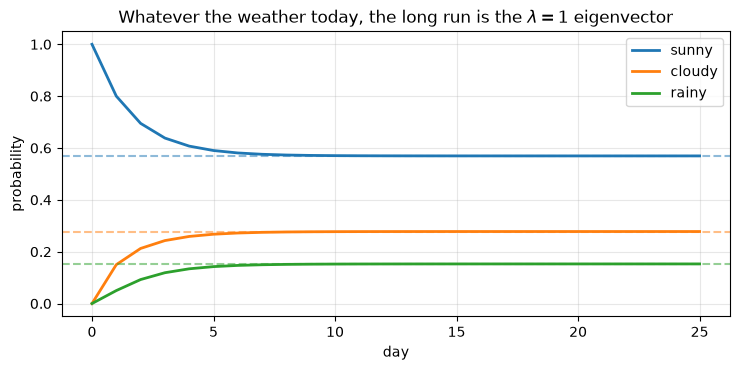

In [10]:
#              to:  sunny  cloudy  rainy      (columns must sum to 1)
T = np.array([[0.80, 0.30, 0.20],       # sunny
              [0.15, 0.50, 0.35],       # cloudy
              [0.05, 0.20, 0.45]])      # rainy
names = ["sunny", "cloudy", "rainy"]
print("columns sum to 1:", T.sum(axis=0))

state = np.array([1.0, 0.0, 0.0])                    # start: definitely sunny
traj = [state]
for _ in range(25):
    state = T @ state
    traj.append(state)
traj = np.array(traj)

vals_t, vecs_t = np.linalg.eig(T)
i1 = int(np.argmin(np.abs(vals_t - 1.0)))
steady = np.abs(vecs_t[:, i1].real); steady /= steady.sum()

print("\neigenvalues of T:", np.round(np.sort(np.abs(vals_t))[::-1], 4), " <- the largest is exactly 1")
print("steady state from the eigenvector:", np.round(steady, 5))
print("after 25 steps of iteration      :", np.round(traj[-1], 5))
print("agree:", np.allclose(steady, traj[-1], atol=1e-4))

plt.figure(figsize=(7.5, 3.8))
for i, nm in enumerate(names):
    plt.plot(traj[:, i], lw=2, label=nm)
    plt.axhline(steady[i], color=f"C{i}", ls="--", alpha=0.5)
plt.xlabel("day"); plt.ylabel("probability"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Whatever the weather today, the long run is the $\\lambda = 1$ eigenvector")
plt.tight_layout(); plt.show()

The second-largest eigenvalue controls how fast it forgets the starting weather:
that is the **mixing rate**, and it is the same $|\lambda_2/\lambda_1|$ ratio
that set the convergence speed of power iteration in Module 2.

## 5.2 PageRank

🧠 **The intuition.** Model a web surfer who clicks a random link on each page.
The fraction of time spent on each page, in the long run, is a measure of that
page's importance, and by the previous section that fraction is the dominant
eigenvector of the link matrix. Google's original insight was that this
eigenvector is a better ranking than counting inbound links, because a link from
an important page counts for more.

📐 **The math.** With $L$ the column-normalised link matrix and a damping factor
$d = 0.85$ (the surfer occasionally teleports to a random page, which keeps the
chain well behaved),

$$ G = d\,L + \frac{1-d}{n}\,\mathbf{1}\mathbf{1}^\top, \qquad G\mathbf{r} = \mathbf{r} $$

💻 **The code.** A six-page toy web.

In [11]:
pages = ["A", "B", "C", "D", "E", "F"]
links = {"A": ["B", "C"], "B": ["C"], "C": ["A"], "D": ["A", "C"],
         "E": ["C", "D"], "F": ["C"]}                 # F links out, nobody links to F

n = len(pages)
L = np.zeros((n, n))
for j, src in enumerate(pages):
    for dst in links[src]:
        L[pages.index(dst), j] = 1.0 / len(links[src])

d = 0.85                                              # <- knob: damping factor
G = d * L + (1 - d) / n * np.ones((n, n))

r_power, iters = np.ones(n) / n, 0
for iters in range(1, 200):
    new = G @ r_power
    if np.linalg.norm(new - r_power, 1) < 1e-12:
        break
    r_power = new

vals_g, vecs_g = np.linalg.eig(G)
r_eig = np.abs(vecs_g[:, int(np.argmin(np.abs(vals_g - 1)))].real); r_eig /= r_eig.sum()

print(f"converged in {iters} iterations\n")
print(f"{'page':>5} {'inbound links':>14} {'PageRank':>10}")
inbound = {p: sum(p in v for v in links.values()) for p in pages}
for i, p in enumerate(pages):
    print(f"{p:>5} {inbound[p]:>14} {r_power[i]:>10.4f}")
print("\npower iteration vs eigenvector solve:", np.allclose(r_power, r_eig, atol=1e-8))
print("ranking:", " > ".join(np.array(pages)[np.argsort(r_power)[::-1]]))

converged in 56 iterations

 page  inbound links   PageRank
    A              2     0.3600
    B              1     0.1780
    C              5     0.3763
    D              1     0.0356
    E              0     0.0250
    F              0     0.0250

power iteration vs eigenvector solve: True
ranking: C > A > B > D > E > F


Compare the two columns. Page **A** has two inbound links against **C**'s five,
and still finishes within a few percent of it, because the page linking to A is
itself highly ranked, which is the recursive definition of importance that
link-counting cannot express. **B** and **D** each have exactly one inbound link
and differ by a factor of five, for the same reason. Pages **E** and **F**
receive nothing and land on $(1-d)/n = 0.025$, the floor that damping hands to
everyone.

The whole computation was: build a matrix, find its dominant eigenvector. At web
scale the matrix has billions of rows and is far too large to factor, but power
iteration only ever needs matrix-vector products, which is precisely why it was
the algorithm of choice.

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| A turn-angle plot with two zeros | Eigenvectors are the directions a matrix does not turn, visible before any algebra |
| $\det(A - \lambda I) = 0$ | The definition, via "singular ⟺ non-trivial null space" from Chapter 6 |
| Trace = $\sum\lambda_i$, det = $\prod\lambda_i$ | Two free sanity checks on any eigenvalue computation |
| `power_iteration` matching its predicted rate | The largest eigenvalue takes over at rate $\lvert\lambda_2/\lambda_1\rvert$; needs only matrix-vector products |
| $A = PDP^{-1}$, $A^k = PD^kP^{-1}$ | Diagonalisation is a change of basis (Chapter 3) chosen to make the matrix trivial |
| Fibonacci → Binet's formula, $\varphi$ | Linear recurrences *are* matrix powers; the golden ratio is a dominant eigenvalue |
| The defective shear, the complex rotation | Diagonalisation can fail: too few eigenvectors, or none that are real |
| Symmetric ⟹ real $\lambda$, orthonormal $Q$ | The spectral theorem, and the reason covariance and Gram matrices are so tractable |
| Markov steady state, PageRank | "Where does repeated application settle?" is always a question about the dominant eigenvector |

**Where the course goes from here.** Eigenvectors are picky. They need a
**square** matrix, and even then they can fail to form a basis. Real data
matrices are rarely square (500 images by 784 pixels, $n$ samples by $p$
features), so the tool of this chapter does not apply to them directly.

**Chapter 9** removes every restriction. The **singular value decomposition**
factors *any* matrix, of any shape, into rotate–stretch–rotate, always with
orthonormal bases and real non-negative stretches. It subsumes eigenvalues,
finishes the least-squares story from Chapter 7, and delivers the promise made
in Chapter 3: the best possible basis for a given set of data, computed rather
than guessed.